In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error

In [15]:
df = pd.read_csv("../data/processed/dk2_merged_price_weather_energy.csv")

df["HourUTC"] = pd.to_datetime(df["HourUTC"])
df["HourDK"] = pd.to_datetime(df["HourDK"])

df = df.sort_values("HourUTC").reset_index(drop=True)

df.head()

,HourUTC,HourDK,PriceArea,SpotPriceEUR,hour,day_of_week,month,year,is_weekend,price_lag_24h,...,offshore_wind_mwh,onshore_wind_mwh,solar_mwh,total_wind_mwh,renewable_generation_mwh,net_load_mwh,ExchangeSE_MWh,ExchangeGE_MWh,ExchangeGreatBelt_MWh,PowerToHeatMWh
0,2024-08-17 06:00:00,2024-08-17 08:00:00,DK2,103.430000,8,5,8,2024,1,124.830002,...,139.575607,12.631012,290.954754,152.206619,443.161373,913.084285,1004.938750,-542.164000,181.2,32.783193
1,2024-08-17 07:00:00,2024-08-17 09:00:00,DK2,84.000000,9,5,8,2024,1,100.949997,...,111.449682,14.223518,464.444211,125.673200,590.117411,897.563125,1164.431492,-839.658984,202.5,24.287895
2,2024-08-17 08:00:00,2024-08-17 10:00:00,DK2,69.489998,10,5,8,2024,1,76.150002,...,86.846481,11.792317,592.522881,98.638798,691.161679,871.185718,1220.923492,-943.107016,244.5,15.592138
3,2024-08-17 09:00:00,2024-08-17 11:00:00,DK2,54.160000,11,5,8,2024,1,59.830002,...,56.012000,14.692761,641.920324,70.704761,712.625085,884.160102,1320.748250,-959.805000,171.9,14.801758
4,2024-08-17 10:00:00,2024-08-17 12:00:00,DK2,46.830002,12,5,8,2024,1,50.680000,...,35.773500,14.832262,675.559553,50.605762,726.165315,868.566350,1008.507250,-865.089992,340.9,12.442353


In [16]:
print("Rows:", len(df))
print("Date range:", df["HourUTC"].min(), "→", df["HourUTC"].max())
print("Missing values:", df.isna().sum())
print("Duplicated HourUTC:", df["HourUTC"].duplicated().sum())

Rows: 9824
Date range: 2024-08-17 06:00:00 → 2025-09-30 13:00:00
Missing values: HourUTC                     0
HourDK                      0
PriceArea                   0
SpotPriceEUR                0
hour                        0
day_of_week                 0
month                       0
year                        0
is_weekend                  0
price_lag_24h               0
price_lag_48h               0
price_lag_168h              0
price_rolling_mean_24h      0
price_rolling_std_24h       0
price_rolling_mean_168h     0
price_rolling_std_168h      0
target_next_hour            0
temperature_2m              0
wind_speed_10m              0
wind_speed_100m             0
cloud_cover                 0
shortwave_radiation         0
GrossConsumptionMWh         0
CentralPowerMWh             0
LocalPowerMWh               0
CommercialPowerMWh          0
offshore_wind_mwh           0
onshore_wind_mwh            0
solar_mwh                   0
total_wind_mwh              0
renewable_generatio

In [17]:
train_size = int(len(df) * 0.7)

train = df.iloc[:train_size].copy()
test = df.iloc[train_size:].copy()
print("Train rows:", len(train))
print("Test rows:", len(test))

print("Train range:", train["HourUTC"].min(), "→", train["HourUTC"].max())
print("Test range:", test["HourUTC"].min(), "→", test["HourUTC"].max())

Train rows: 6876
Test rows: 2948
Train range: 2024-08-17 06:00:00 → 2025-05-30 17:00:00
Test range: 2025-05-30 18:00:00 → 2025-09-30 13:00:00


In [18]:
test["pred_current_price"] = test["SpotPriceEUR"]
test["pred_lag_24h"] = test["price_lag_24h"]
test["pred_lag_168h"] = test["price_lag_168h"]
test["pred_rolling_mean_24h"] = test["price_rolling_mean_24h"]
test["pred_rolling_mean_168h"] = test["price_rolling_mean_168h"]

In [19]:
def evaluate_forecast(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    return {
        "model": model_name,
        "MAE": round(mae, 2),
        "RMSE": round(rmse, 2),
    }

In [20]:
results = []

results.append(evaluate_forecast(
    test["target_next_hour"],
    test["pred_current_price"],
    "Current price baseline"
))

results.append(evaluate_forecast(
    test["target_next_hour"],
    test["pred_lag_24h"],
    "Lag 24h baseline"
))

results.append(evaluate_forecast(
    test["target_next_hour"],
    test["pred_lag_168h"],
    "Lag 168h baseline"
))

results.append(evaluate_forecast(
    test["target_next_hour"],
    test["pred_rolling_mean_24h"],
    "Rolling mean 24h baseline"
))

results.append(evaluate_forecast(
    test["target_next_hour"],
    test["pred_rolling_mean_168h"],
    "Rolling mean 168h baseline"
))

results_df = pd.DataFrame(results)
results_df

,model,MAE,RMSE
0,Current price baseline,14.62,24.98
1,Lag 24h baseline,31.85,46.71
2,Lag 168h baseline,33.83,50.63
3,Rolling mean 24h baseline,34.51,45.80
4,Rolling mean 168h baseline,36.62,48.67


In [21]:
results_df = results_df.sort_values("MAE").reset_index(drop=True)
results_df

,model,MAE,RMSE
0,Current price baseline,14.62,24.98
1,Lag 24h baseline,31.85,46.71
2,Lag 168h baseline,33.83,50.63
3,Rolling mean 24h baseline,34.51,45.80
4,Rolling mean 168h baseline,36.62,48.67


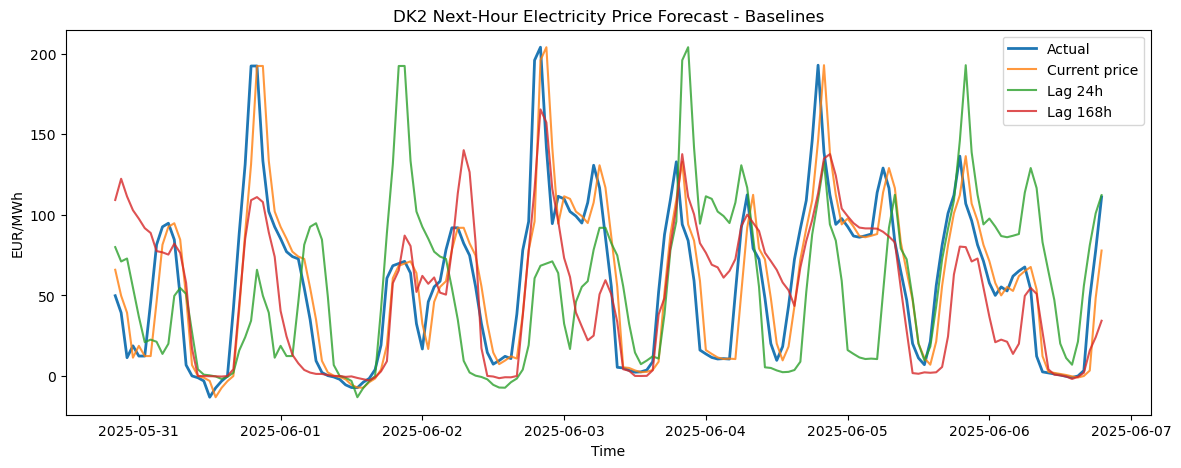

In [22]:
sample = test.head(168)

plt.figure(figsize=(14, 5))

plt.plot(
    sample["HourDK"],
    sample["target_next_hour"],
    label="Actual",
    linewidth=2
)

plt.plot(
    sample["HourDK"],
    sample["pred_current_price"],
    label="Current price",
    alpha=0.8
)

plt.plot(
    sample["HourDK"],
    sample["pred_lag_24h"],
    label="Lag 24h",
    alpha=0.8
)

plt.plot(
    sample["HourDK"],
    sample["pred_lag_168h"],
    label="Lag 168h",
    alpha=0.8
)

plt.title("DK2 Next-Hour Electricity Price Forecast - Baselines")
plt.xlabel("Time")
plt.ylabel("EUR/MWh")
plt.legend()
plt.show()

In [23]:
from pathlib import Path

reports_dir = Path("../reports")
reports_dir.mkdir(parents=True, exist_ok=True)

results_df.to_csv("../reports/baseline_results_DK2.csv", index=False)